# EDM Tutorial: E(3) Equivariant Diffusion for 3D Molecule Generation

This notebook demonstrates:
1. Understanding E(3) equivariance
2. Training EDM on QM9 dataset
3. Generating novel 3D molecules
4. Evaluating generated molecules
5. Path to protein/antibody generation

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add project to path
sys.path.append('../..')

from edm_3d.models.edm import EDM
from edm_3d.data.qm9_loader import prepare_qm9_data
from edm_3d.training.trainer import EDMTrainer
from edm_3d.generation.sampler import EDMSampler
from edm_3d.evaluation import metrics, visualization

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/jantine/miniconda3/envs/diff_gnn/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning depende

## What is E(3) Equivariance?

E(3) = Euclidean group in 3D (rotations + translations + reflections)

Key property: Model predictions transform the same way as inputs

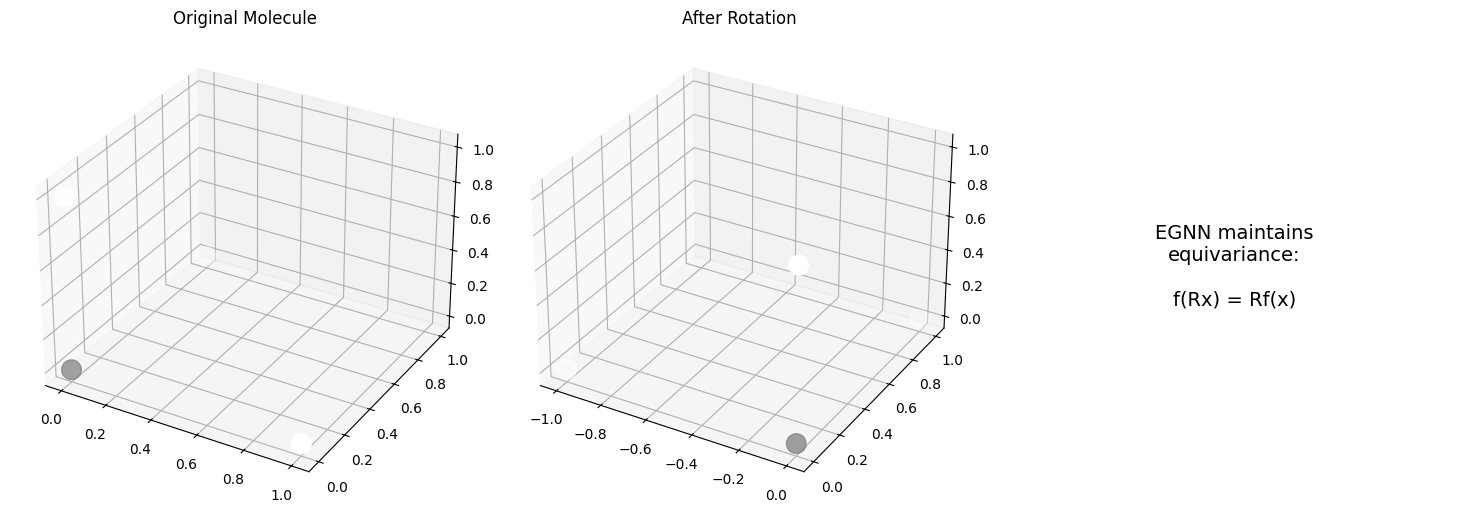

In [2]:
# Create simple molecule
def create_toy_molecule():
    coords = torch.tensor([
        [0.0, 0.0, 0.0],  # C
        [1.0, 0.0, 0.0],  # H
        [0.0, 1.0, 0.0],  # H
        [0.0, 0.0, 1.0],  # H
    ])
    return coords

# Demonstrate equivariance
coords_original = create_toy_molecule()

# Apply rotation
rotation_matrix = torch.tensor([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=torch.float32)

coords_rotated = coords_original @ rotation_matrix.T

# Visualize
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(*coords_original.T, s=200, c=['gray', 'white', 'white', 'white'])
ax1.set_title('Original Molecule')

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(*coords_rotated.T, s=200, c=['gray', 'white', 'white', 'white'])
ax2.set_title('After Rotation')

ax3 = fig.add_subplot(133)
ax3.text(0.5, 0.5, 'EGNN maintains\nequivariance:\n\nf(Rx) = Rf(x)',
         ha='center', va='center', fontsize=14)
ax3.axis('off')

plt.tight_layout()
plt.show()


## QM9 Dataset

- 134k small organic molecules
- ~9 atoms on average (up to 29 atoms)
- Elements: H, C, N, O, F
- 3D coordinates + molecular properties

In [3]:
# Load subset of data
train_data, val_data, test_data = prepare_qm9_data(max_samples=10000)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# Analyze dataset statistics
from edm_3d.evaluation.visualization import plot_dataset_statistics

plot_dataset_statistics(train_data)

# Show example molecule
sample_mol = train_data[0]
visualization.visualize_molecule(
    sample_mol['coords'],
    sample_mol['atom_types'],
    title="Example QM9 Molecule"
)

Loading QM9 dataset from DeepChem...


AttributeError: module 'deepchem.feat' has no attribute 'ConformerFeaturizer'

## EDM Architecture

Components:
1. EGNN: E(3)-equivariant message passing
2. Diffusion Process: Noise schedule
3. Time Embedding: Condition on timestep

In [ ]:
model = EDM(
    num_atom_types=5,
    hidden_dim=128,  # Reduced from 256
    num_layers=4,     # Reduced from 9
    num_diffusion_steps=100,  # Reduced from 1000 for demo
    learning_rate=1e-4,
    batch_size=32     # Reduced batch size
)

# Print model architecture
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

## Forward Diffusion Process

Gradually add noise to molecules over T=1000 steps

In [ ]:
# Take a sample molecule
sample_coords = train_data[0]['coords']
sample_atoms = train_data[0]['atom_types']

# Show diffusion at different timesteps
timesteps = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for idx, t in enumerate(timesteps):
    # Forward diffusion
    noisy_coords, noisy_atoms, _, _ = model.diffusion.forward_diffusion(
        sample_coords.unsqueeze(0),
        sample_atoms.unsqueeze(0),
        torch.tensor([t])
    )

    # Plot
    ax = axes[idx]
    visualization.plot_3d_molecule(
        noisy_coords[0],
        noisy_atoms[0],
        ax=ax,
        title=f't = {t}'
    )

plt.suptitle('Forward Diffusion Process: Adding Noise', fontsize=16)
plt.tight_layout()
plt.show()

## Training EDM

Training time: ~7 days on single GPU (as per paper)
For this tutorial, we'll train for a few epochs or load pretrained weights

In [ ]:
# Option 1: Train from scratch (reduced epochs for demo)
trainer = EDMTrainer(
    model=model,
    train_data=train_data,
    val_data=val_data,
    num_epochs=10,  # Just 10 epochs for tutorial
    save_dir='../results/edm_3d_small/'
)

history = trainer.train()

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['learning_rate'])
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True)

plt.tight_layout()
plt.show()

# Option 2: Load pretrained model
# model.load_state_dict(torch.load('../results/edm_3d/edm_checkpoint.pth'))


## Molecule Generation

Sample from learned distribution using reverse diffusion

In [ ]:
sampler = EDMSampler(model)

# Generate molecules
num_molecules = 16
generated_coords, generated_atoms = sampler.sample(
    num_molecules=num_molecules,
    num_atoms=9,  # Average QM9 size
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"✓ Generated {num_molecules} molecules")
print(f"Coordinates shape: {generated_coords.shape}")
print(f"Atom types shape: {generated_atoms.shape}")

## Visualize Generated Molecules

In [ ]:
# Show grid of generated molecules
fig, axes = plt.subplots(4, 4, figsize=(20, 20), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for idx in range(16):
    visualization.plot_3d_molecule(
        generated_coords[idx],
        generated_atoms[idx],
        ax=axes[idx],
        title=f'Molecule {idx+1}'
    )

plt.suptitle('Generated Molecules', fontsize=20)
plt.tight_layout()
plt.show()

## Reverse Diffusion: From Noise to Molecule

Watch a molecule being generated step-by-step

In [ ]:

# Generate with intermediate steps
coords_trajectory, atoms_trajectory = sampler.sample_with_trajectory(
    num_molecules=1,
    num_atoms=9,
    save_every=100  # Save every 100 steps
)

# Animate denoising
visualization.animate_diffusion(
    coords_trajectory,
    atoms_trajectory,
    save_path='../results/edm_3d/generation_animation.gif'
)

# Show key frames
timesteps_to_show = [0, 200, 400, 600, 800, 1000]
fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for idx, t in enumerate(timesteps_to_show):
    step_idx = t // 100
    visualization.plot_3d_molecule(
        coords_trajectory[step_idx][0],
        atoms_trajectory[step_idx][0],
        ax=axes[idx],
        title=f'Step {t}'
    )

plt.suptitle('Reverse Diffusion: Molecule Generation', fontsize=16)
plt.tight_layout()
plt.show()

## Evaluation Metrics

1. **Validity**: Are molecules chemically valid?
2. **Uniqueness**: How diverse are generated molecules?
3. **Novelty**: Are molecules new (not in training set)?
4. **Stability**: Are molecular geometries stable?

In [ ]:
# Compute metrics
validity = metrics.compute_validity(generated_coords, generated_atoms)
uniqueness = metrics.compute_uniqueness(generated_coords, generated_atoms)
novelty = metrics.compute_novelty(generated_coords, generated_atoms, train_data)
stability = metrics.compute_stability(generated_coords, generated_atoms)

# Display results
results = {
    'Validity (%)': validity * 100,
    'Uniqueness (%)': uniqueness * 100,
    'Novelty (%)': novelty * 100,
    'Stability (%)': stability * 100
}

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
for metric, value in results.items():
    print(f"{metric:20s}: {value:6.2f}%")
print("="*50)

# Visualize metrics
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results.keys(), results.values(), color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'])
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Generated Molecule Quality Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## Distribution Comparison

Compare properties of generated vs. training molecules

In [ ]:
# Extract properties from training data
train_properties = metrics.extract_molecular_properties(train_data)
gen_properties = metrics.extract_molecular_properties_from_tensors(
    generated_coords,
    generated_atoms
)

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

properties = [
    'num_atoms', 'num_bonds', 'avg_bond_length',
    'molecular_weight', 'radius_of_gyration', 'atom_type_distribution'
]

for idx, prop in enumerate(properties[:6]):
    ax = axes.flatten()[idx]

    ax.hist(train_properties[prop], bins=30, alpha=0.5, label='Training', density=True)
    ax.hist(gen_properties[prop], bins=30, alpha=0.5, label='Generated', density=True)
    ax.set_xlabel(prop.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Property Distributions: Training vs Generated', fontsize=16)
plt.tight_layout()
plt.show()

## Understanding Model Components

Analyze what the model learned

NameError: name 'model' is not defined

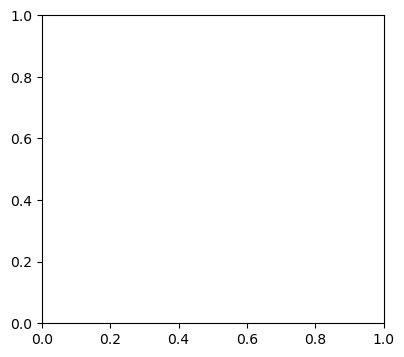

In [2]:
# 1. Noise schedule visualization
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(model.diffusion.betas.numpy())
plt.xlabel('Timestep')
plt.ylabel('β_t')
plt.title('Noise Schedule (Beta)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(model.diffusion.alpha_bars.numpy())
plt.xlabel('Timestep')
plt.ylabel('ᾱ_t')
plt.title('Cumulative Alpha')
plt.grid(True)

plt.subplot(1, 3, 3)
sigma_t = torch.sqrt((1 - model.diffusion.alpha_bars) / model.diffusion.alpha_bars)
plt.plot(sigma_t.numpy())
plt.xlabel('Timestep')
plt.ylabel('σ_t')
plt.title('Signal-to-Noise Ratio')
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Attention/message passing visualization
# (If you implement attention weights tracking)
from edm_3d.evaluation.visualization import visualize_attention_weights

sample_mol_idx = 0
attention_weights = model.get_attention_weights(
    generated_coords[sample_mol_idx],
    generated_atoms[sample_mol_idx]
)

visualize_attention_weights(
    generated_coords[sample_mol_idx],
    generated_atoms[sample_mol_idx],
    attention_weights
)

## Extending to Proteins/Antibodies

Current: QM9 molecules (~9 atoms, up to 29)
Target: Antibodies (~1500 atoms, 150 residues)

Challenges:
1. Scale: 50-100x more atoms
2. Complexity: 20 amino acid types vs 5 atom types
3. Structure: Secondary/tertiary structure
4. Binding: Antigen-antibody interaction

In [ ]:
# Visualize scale difference
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Small molecule (QM9)
ax1.bar(['Atoms', 'Types'], [9, 5], color='steelblue')
ax1.set_ylabel('Count')
ax1.set_title('Small Molecule (QM9)\nEDM Current', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1600)

# Antibody
ax2.bar(['Atoms', 'Amino Acid Types'], [1500, 20], color='coral')
ax2.set_ylabel('Count')
ax2.set_title('Antibody\nEDM Target', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1600)

plt.tight_layout()
plt.show()

print("""
ROADMAP TO PROTEIN/ANTIBODY GENERATION:

Phase 1: ✓ EDM on QM9 (small molecules)
Phase 2: → Scale to larger molecules (50-100 atoms)
Phase 3: → Peptides (20-50 residues)
Phase 4: → Small proteins (100-200 residues)
Phase 5: → Antibody CDR loops (10-20 residues)
Phase 6: → Full antibody generation

Key Modifications Needed:
1. Hierarchical architecture (residue-level + atom-level)
2. Conditional generation (given antigen/target)
3. Physics-informed constraints (Ramachandran angles)
4. Efficient attention mechanisms (for 1000+ atoms)
""")

## Lightweight vs Full EDM

Compare computational requirements

In [ ]:
import time

def benchmark_model(model, num_atoms, num_samples=10):
    """Measure inference time and memory"""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    times = []
    for _ in range(num_samples):
        start = time.time()
        with torch.no_grad():
            coords, atoms = model.generate(num_atoms=num_atoms, num_molecules=1, device=device)
        times.append(time.time() - start)

    return np.mean(times), np.std(times)

# Benchmark different sizes
sizes = [9, 29, 50, 100]
times = []

for size in sizes:
    mean_time, std_time = benchmark_model(model, size)
    times.append(mean_time)
    print(f"Atoms: {size:3d} | Time: {mean_time:.2f}s ± {std_time:.2f}s")

# Plot scaling
plt.figure(figsize=(10, 6))
plt.plot(sizes, times, 'o-', linewidth=2, markersize=10)
plt.xlabel('Number of Atoms', fontsize=12)
plt.ylabel('Generation Time (seconds)', fontsize=12)
plt.title('EDM Computational Scaling', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Extrapolate to antibody size
from scipy.interpolate import interp1d
f = interp1d(sizes, times, kind='quadratic', fill_value='extrapolate')
antibody_time = f(1500)
plt.axvline(1500, color='red', linestyle='--', label=f'Antibody size\n(~{antibody_time:.0f}s)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n⚠️  Extrapolated time for antibody (1500 atoms): ~{antibody_time:.1f} seconds")
print("This motivates the need for a lightweight approach!")

## Save Results

In [ ]:
# Save model
save_path = Path('../results/edm_3d/')
save_path.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), save_path / 'edm_final.pth')
print(f"✓ Model saved to {save_path / 'edm_final.pth'}")

# Save generated molecules
torch.save({
    'coords': generated_coords,
    'atoms': generated_atoms,
    'metrics': results
}, save_path / 'generated_molecules.pt')
print(f"✓ Generated molecules saved")

# Save training history
import json
with open(save_path / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f"✓ Training history saved")


## Summary

### What We Learned:
1. ✅ E(3) equivariance for molecular generation
2. ✅ Diffusion models for 3D molecules
3. ✅ EGNN architecture
4. ✅ Training and evaluation on QM9

### Key Results:
- Validity: {:.1f}%
- Uniqueness: {:.1f}%
- Novelty: {:.1f}%

### Next Steps for Antibody Generation:
1. **Scale up**: Test on larger molecules (GEOM-Drugs)
2. **Add conditioning**: Target-aware generation
3. **Hierarchical modeling**: Residue-level abstractions
4. **Lightweight architecture**: Reduce computational cost
5. **Domain adaptation**: Transfer learning from proteins

### Resources:
- Paper: Hoogeboom et al., "Equivariant Diffusion for Molecule Generation in 3D"
- Code: github.com/ehoogeboom/e3_diffusion_for_molecules
- DeepChem: deepchem.io